In [5]:
## STEP 1 IMPORT LIBRARY

import os
import pandas as pd
import numpy as np
import librosa
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (confusion_matrix, accuracy_score,
                             precision_score, recall_score, f1_score,
                             classification_report)
import warnings
warnings.filterwarnings('ignore')

In [6]:
## STEP 2 LOAD DATASET

# Path ke file metadata dan folder audio
metadata_path = 'validated.tsv'
audio_folder = 'clips'

# Membaca metadata
df = pd.read_csv(metadata_path, sep='\t')
print(f"Jumlah data awal: {len(df)}")
print(df.head())

Jumlah data awal: 30331
                                           client_id  \
0  00f046cd1abd7e4ed354c2d97b67aceee8deb20bf53e5c...   
1  018b3f1a0a941a5b881a886830d9f133402ed66409489a...   
2  025f07759891360d312521dd83679fa6a233b9d7aa9d4a...   
3  0a4e7e60acc2a6145fc2589e6abb81e41e430cea0611bd...   
4  0a64c046530244b7507d4404575e8f673613c939ad6fac...   

                           path  \
0  common_voice_id_39599471.mp3   
1  common_voice_id_32165882.mp3   
2  common_voice_id_27657418.mp3   
3  common_voice_id_23033570.mp3   
4  common_voice_id_40088845.mp3   

                                         sentence_id  \
0  05e82b3c6f238b34985f158c4b63a8a9fda0382f1bd798...   
1  dd457d82f974202742803bf426f129d339fb1cf2217876...   
2  34f56b62e91fbbffeb7df499d4486aaa9f6d963a93d57f...   
3  ecee266f978e8296fc17d2bcfa744429165db882dbe5fd...   
4  67125efffe8d90c1147d6d609ca9e041f17b1a78b6a3d2...   

                                            sentence  sentence_domain  \
0                D

In [7]:
## STEP 3 FILTER DATASET

# Filter hanya dua kelas yang diinginkan
df_filtered = df[df['gender'].isin(['male_masculine', 'female_feminine'])].copy()
print(f"Jumlah data setelah filter: {len(df_filtered)}")
print("Distribusi gender:")
print(df_filtered['gender'].value_counts())

Jumlah data setelah filter: 21587
Distribusi gender:
gender
male_masculine     13983
female_feminine     7604
Name: count, dtype: int64


In [8]:
## STEP 4 VALIDATE AUDIO FILES

# Daftar path file audio yang valid
valid_paths = []
for idx, row in df_filtered.iterrows():
    audio_path = os.path.join(audio_folder, row['path'])
    if os.path.exists(audio_path):
        valid_paths.append(idx)

df_filtered = df_filtered.loc[valid_paths].reset_index(drop=True)
print(f"Jumlah data setelah validasi file: {len(df_filtered)}")

Jumlah data setelah validasi file: 21587


In [9]:
##STEP 5 Menentukan parameter eksperimen

# Parameter eksperimen
N_MFCC = 24          # M4
K = 3                # K1

print(f"Eksperimen: MFCC={N_MFCC}, K={K}")

Eksperimen: MFCC=24, K=3


In [10]:
## STEP 6 Menentukan parameter audio

TARGET_SR = 16000
PRE_EMPHASIS = 0.97

# Parameter framing
FRAME_LENGTH_MS = 25
HOP_LENGTH_MS = 10

# Konversi milidetik ke jumlah sample
WIN_LENGTH = int(
    TARGET_SR * FRAME_LENGTH_MS / 1000
)

HOP_LENGTH = int(
    TARGET_SR * HOP_LENGTH_MS / 1000
)

# FFT
N_FFT = 512

print(f"Target Sample Rate : {TARGET_SR} Hz")
print(f"Pre-emphasis       : {PRE_EMPHASIS}")
print(f"MFCC               : {N_MFCC}")
print(f"K                  : {K}")
print(f"Frame Length       : {FRAME_LENGTH_MS} ms ({WIN_LENGTH} samples)")
print(f"Hop Length         : {HOP_LENGTH_MS} ms ({HOP_LENGTH} samples)")
print(f"N FFT              : {N_FFT}")

Target Sample Rate : 16000 Hz
Pre-emphasis       : 0.97
MFCC               : 24
K                  : 3
Frame Length       : 25 ms (400 samples)
Hop Length         : 10 ms (160 samples)
N FFT              : 512


In [11]:
### STEP 7 EKSTRAKSI FITUR MFCC

def extract_mfcc(
    file_path,
    n_mfcc=13,
    target_sr=16000,
    pre_emphasis=0.97,
    win_length=400,
    hop_length=160,
    n_fft=512
):
    try:

        # ==========================================
        # 1. LOAD AUDIO
        # ==========================================
        # Resampling ke 16 kHz
        # Mono = True memastikan audio menjadi mono

        y, sr = librosa.load(
            file_path,
            sr=target_sr,
            mono=True
        )

        # ==========================================
        # 2. PRE-EMPHASIS
        # ==========================================

        y = np.append(
            y[0],
            y[1:] - pre_emphasis * y[:-1]
        )

        # ==========================================
        # 3. EKSTRAKSI MFCC
        # ==========================================

        mfcc = librosa.feature.mfcc(
            y=y,
            sr=sr,
            n_mfcc=n_mfcc,
            n_fft=n_fft,
            win_length=win_length,
            hop_length=hop_length
        )

        # ==========================================
        # 4. RATA-RATA MFCC
        # ==========================================

        mfcc_mean = np.mean(
            mfcc,
            axis=1
        )

        return mfcc_mean

    except Exception as e:

        print(
            f"Error pada file {file_path}: {e}"
        )

        return None

In [12]:
##STEP 7 Ekstrak fitur untuk semua file audio
from tqdm import tqdm

X = []
y = []

for idx, row in df_filtered.iterrows():

    audio_path = os.path.join(
        audio_folder,
        row['path']
    )

    features = extract_mfcc(
        audio_path,
        n_mfcc=N_MFCC,
        target_sr=TARGET_SR,
        pre_emphasis=PRE_EMPHASIS,
        win_length=WIN_LENGTH,
        hop_length=HOP_LENGTH,
        n_fft=N_FFT
    )

    if features is not None:

        X.append(features)
        y.append(row['gender'])

# Konversi ke numpy array
X = np.array(X)
y = np.array(y)

print(
    f"Jumlah fitur yang berhasil diekstrak: "
    f"{X.shape[0]}"
)

print(
    f"Dimensi fitur: "
    f"{X.shape[1]}"
)

Jumlah fitur yang berhasil diekstrak: 21587
Dimensi fitur: 24


In [13]:
##STEP 8 Distribusi label setelah ekstraksi

unique, counts = np.unique(
    y,
    return_counts=True
)

print("Distribusi label setelah ekstraksi:")

for label, count in zip(
    unique,
    counts
):

    print(f"{label}: {count}")

Distribusi label setelah ekstraksi:
female_feminine: 7604
male_masculine: 13983


In [14]:
## STEP 9 Encode label

le = LabelEncoder()

y_encoded = le.fit_transform(y)

print(
    "Label mapping:"
)

print(
    dict(
        zip(
            le.classes_,
            le.transform(le.classes_)
        )
    )
)

Label mapping:
{np.str_('female_feminine'): np.int64(0), np.str_('male_masculine'): np.int64(1)}


In [15]:
##STEP 10 Split data menjadi training dan testing

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    stratify=y_encoded
)

print(
    f"Training set size: "
    f"{X_train.shape[0]}"
)

print(
    f"Testing set size: "
    f"{X_test.shape[0]}"
)

Training set size: 17269
Testing set size: 4318


In [16]:
## STEP 11 Standarisasi fitur

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

print("Standarisasi selesai.")

Standarisasi selesai.


In [17]:
## STEP 12 Buat model KNN

knn = KNeighborsClassifier(
    n_neighbors=K
)

print(
    f"Model KNN dengan K={K} dibuat."
)

Model KNN dengan K=3 dibuat.


In [18]:
##STEP 13 Latih model KNN

knn.fit(
    X_train_scaled,
    y_train
)

print("Training selesai.")

Training selesai.


In [19]:
##STEP 14 Prediksi pada data testing

y_pred = knn.predict(
    X_test_scaled
)

print("Prediksi selesai.")

Prediksi selesai.


In [20]:
## STEP 15 Evaluasi model

# CONFUSION MATRIX
# ==========================================
cm = confusion_matrix(
    y_test,
    y_pred
)

print("Confusion Matrix:")
print(cm)


# ==========================================
# METRICS
# ==========================================

acc = accuracy_score(
    y_test,
    y_pred
)

prec = precision_score(
    y_test,
    y_pred,
    average='binary'
)

rec = recall_score(
    y_test,
    y_pred,
    average='binary'
)

f1 = f1_score(
    y_test,
    y_pred,
    average='binary'
)


print(f"\nAccuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1-Score  : {f1:.4f}")


# ==========================================
# CLASSIFICATION REPORT
# ==========================================

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=le.classes_
    )
)

Confusion Matrix:
[[1495   26]
 [  18 2779]]

Accuracy  : 0.9898
Precision : 0.9907
Recall    : 0.9936
F1-Score  : 0.9921

Classification Report:
                 precision    recall  f1-score   support

female_feminine       0.99      0.98      0.99      1521
 male_masculine       0.99      0.99      0.99      2797

       accuracy                           0.99      4318
      macro avg       0.99      0.99      0.99      4318
   weighted avg       0.99      0.99      0.99      4318



In [21]:
##STEP 16 Tampilkan hasil eksperimen

print("\n=== HASIL EKSPERIMEN ===")
print(f"MFCC = {N_MFCC}, K = {K}")
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1-Score  : {f1:.4f}")
print("Confusion Matrix:")
print(cm)


=== HASIL EKSPERIMEN ===
MFCC = 24, K = 3
Accuracy  : 0.9898
Precision : 0.9907
Recall    : 0.9936
F1-Score  : 0.9921
Confusion Matrix:
[[1495   26]
 [  18 2779]]


In [22]:
## STEP 17.1 LOAD DATA EKSTERNAL

external_folder = 'Dataeksternal'

external_files = []
external_labels = []

for label in ['female_feminine', 'male_masculine']:

    folder_path = os.path.join(
        external_folder,
        label
    )

    for filename in os.listdir(folder_path):

        if filename.lower().endswith('.mp3'):

            external_files.append(
                os.path.join(folder_path, filename)
            )

            external_labels.append(label)

print(f"Jumlah data eksternal: {len(external_files)}")

Jumlah data eksternal: 100


In [23]:
## STEP 17.2 EKSTRAKSI MFCC DATA EKSTERNAL

X_external = []
y_external = []
failed_files = []

for audio_path, label in zip(external_files, external_labels):

    try:
        # Coba baca audio menggunakan librosa
        y, sr = librosa.load(
            audio_path,
            sr=TARGET_SR,
            mono=True
        )

    except Exception:
        try:
            # Jika librosa gagal, baca menggunakan soundfile
            y, sr = sf.read(audio_path)

            # Jika stereo, ubah menjadi mono
            if len(y.shape) > 1:
                y = np.mean(y, axis=1)

            # Resampling ke 16 kHz
            if sr != TARGET_SR:
                y = librosa.resample(
                    y.astype(np.float32),
                    orig_sr=sr,
                    target_sr=TARGET_SR
                )
                sr = TARGET_SR

        except Exception as e:
            print(f"Gagal membaca file: {audio_path}")
            print(f"Error: {e}")
            failed_files.append(audio_path)
            continue

    try:
        # Pre-emphasis
        y = np.append(
            y[0],
            y[1:] - PRE_EMPHASIS * y[:-1]
        )

        # Ekstraksi MFCC
        mfcc = librosa.feature.mfcc(
            y=y,
            sr=TARGET_SR,
            n_mfcc=N_MFCC,
            n_fft=N_FFT,
            win_length=WIN_LENGTH,
            hop_length=HOP_LENGTH
        )

        # Rata-rata MFCC sepanjang waktu
        features = np.mean(mfcc, axis=1)

        X_external.append(features)
        y_external.append(label)

    except Exception as e:
        print(f"Gagal ekstraksi MFCC: {audio_path}")
        print(f"Error: {e}")
        failed_files.append(audio_path)


# Ubah menjadi NumPy array
X_external = np.array(X_external)
y_external = np.array(y_external)

print("\n=== HASIL EKSTRAKSI DATA EKSTERNAL ===")
print(f"Jumlah data berhasil diekstrak: {X_external.shape[0]}")
print(f"Dimensi fitur MFCC: {X_external.shape[1]}")
print(f"Jumlah data gagal: {len(failed_files)}")

if len(failed_files) > 0:
    print("\nFile yang gagal:")
    for file in failed_files:
        print(file)

Gagal membaca file: Dataeksternal\female_feminine\AUDIO-2026-09-02-06-07-17 (2).mp3
Error: name 'sf' is not defined
Gagal membaca file: Dataeksternal\female_feminine\AUDIO-2026-09-02-06-07-18 (1).mp3
Error: name 'sf' is not defined

=== HASIL EKSTRAKSI DATA EKSTERNAL ===
Jumlah data berhasil diekstrak: 98
Dimensi fitur MFCC: 24
Jumlah data gagal: 2

File yang gagal:
Dataeksternal\female_feminine\AUDIO-2026-09-02-06-07-17 (2).mp3
Dataeksternal\female_feminine\AUDIO-2026-09-02-06-07-18 (1).mp3


In [24]:
## STEP 17.3 LABEL DATA EKSTERNAL

y_external_encoded = le.transform(y_external)

print("Distribusi label data eksternal:")
print(pd.Series(y_external).value_counts())

Distribusi label data eksternal:
male_masculine     50
female_feminine    48
Name: count, dtype: int64


In [25]:
## STEP 17.4 STANDARDISASI DATA EKSTERNAL

X_external_scaled = scaler.transform(
    X_external
)

print("Standardisasi data eksternal selesai.")

Standardisasi data eksternal selesai.


In [26]:
## STEP 17.5 PREDIKSI DATA EKSTERNAL

y_external_pred = knn.predict(
    X_external_scaled
)

print("Prediksi data eksternal selesai.")

Prediksi data eksternal selesai.


=== HASIL PENGUJIAN DATA EKSTERNAL ===
Accuracy  : 0.8469
Precision : 0.7966
Recall    : 0.9400
F1-Score  : 0.8624

Confusion Matrix:
[[36 12]
 [ 3 47]]


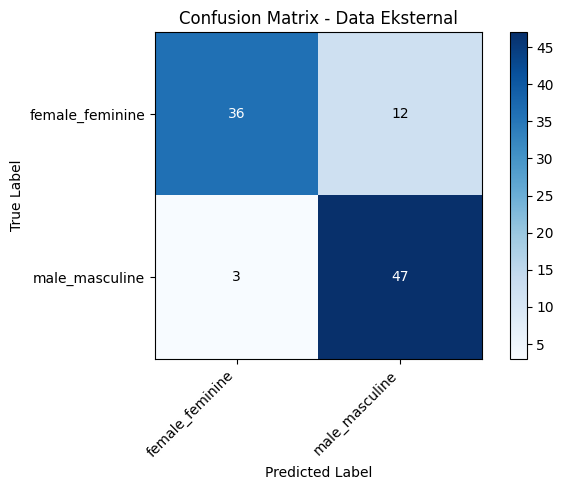

In [27]:
## STEP 17.6 EVALUASI DATA EKSTERNAL

import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

cm_external = confusion_matrix(
    y_external_encoded,
    y_external_pred
)

acc_external = accuracy_score(
    y_external_encoded,
    y_external_pred
)

prec_external = precision_score(
    y_external_encoded,
    y_external_pred,
    average='binary'
)

rec_external = recall_score(
    y_external_encoded,
    y_external_pred,
    average='binary'
)

f1_external = f1_score(
    y_external_encoded,
    y_external_pred,
    average='binary'
)

print("=== HASIL PENGUJIAN DATA EKSTERNAL ===")

print(f"Accuracy  : {acc_external:.4f}")
print(f"Precision : {prec_external:.4f}")
print(f"Recall    : {rec_external:.4f}")
print(f"F1-Score  : {f1_external:.4f}")

print("\nConfusion Matrix:")
print(cm_external)

plt.figure(figsize=(7, 5))
plt.imshow(cm_external, interpolation='nearest', cmap='Blues')
plt.title('Confusion Matrix - Data Eksternal')
plt.colorbar()
plt.xticks(
    np.arange(len(le.classes_)),
    le.classes_,
    rotation=45,
    ha='right'
)
plt.yticks(np.arange(len(le.classes_)), le.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

threshold = cm_external.max() / 2
for row_index in range(cm_external.shape[0]):
    for column_index in range(cm_external.shape[1]):
        plt.text(
            column_index,
            row_index,
            cm_external[row_index, column_index],
            ha='center',
            va='center',
            color='white' if cm_external[row_index, column_index] > threshold else 'black'
        )

plt.tight_layout()
plt.show()

In [28]:
test_files = [
    r"Dataeksternal\female_feminine\AUDIO-2026-09-02-06-07-17 (2).mp3",
    r"Dataeksternal\female_feminine\AUDIO-2026-09-02-06-07-18 (1).mp3"
]

for audio_path in test_files:
    print("\nMengecek:", audio_path)

    try:
        y, sr = librosa.load(audio_path, sr=16000, mono=True)

        print("Berhasil dibaca")
        print("Sample rate:", sr)
        print("Jumlah sample:", len(y))
        print("Durasi:", len(y) / sr, "detik")

    except Exception as e:
        print("ERROR SEBENARNYA:")
        print(repr(e))


Mengecek: Dataeksternal\female_feminine\AUDIO-2026-09-02-06-07-17 (2).mp3
ERROR SEBENARNYA:
NoBackendError()

Mengecek: Dataeksternal\female_feminine\AUDIO-2026-09-02-06-07-18 (1).mp3
ERROR SEBENARNYA:
NoBackendError()


In [29]:
import soundfile as sf

for audio_path in test_files:
    print("\nMengecek:", audio_path)

    try:
        info = sf.info(audio_path)
        print(info)

    except Exception as e:
        print("ERROR:")
        print(repr(e))


Mengecek: Dataeksternal\female_feminine\AUDIO-2026-09-02-06-07-17 (2).mp3
Dataeksternal\female_feminine\AUDIO-2026-09-02-06-07-17 (2).mp3
samplerate: 48000 Hz
channels: 2
duration: 7.131 s
format: MPEG-1/2 Audio [MP3]
subtype: MPEG Layer III [MPEG_LAYER_III]

Mengecek: Dataeksternal\female_feminine\AUDIO-2026-09-02-06-07-18 (1).mp3
Dataeksternal\female_feminine\AUDIO-2026-09-02-06-07-18 (1).mp3
samplerate: 48000 Hz
channels: 2
duration: 7.731 s
format: MPEG-1/2 Audio [MP3]
subtype: MPEG Layer III [MPEG_LAYER_III]
